# 기능 1 — 최종 모델 선정용 비교 실험 (Sentiment Analysis)

> ⚠️ **이 노트북은 최종 제출 모델이 아니라, 실제로 어떤 모델을 쓸지 "정하기 위한" 비교(시뮬레이션) 과정입니다.**
> 여러 후보 모델을 같은 조건에서 돌려 보고, 그 결과를 근거로 최종 모델을 선택합니다.
> 여기서 선정된 모델의 정식 학습·평가는 `sentiment_analysis.ipynb` 에서 진행합니다.

기능 1(감정 긍정/부정 이진 분류)의 후보 모델을 **완전히 동일한 데이터 분할 / 동일한 Test set**으로 평가하여 공정하게 비교합니다.

- **후보 1**: KLUE-RoBERTa (`klue/roberta-base`) 단독 — 한국어 사전학습 딥러닝 모델
- **후보 2**: KcELECTRA + SVM(TF-IDF) **7:3 Soft Voting 앙상블**
- **후보 3**: KcELECTRA + Bi-LSTM **7:3 Soft Voting 앙상블**

> **공정 비교 원칙**: 세 후보 모두 `Seed=42`, `Stratified 8:1:1` 분할로 만든 **같은 Train/Val/Test** 를 사용합니다.
> 후보 2·3은 동일한 KcELECTRA(딥러닝) 백본을 공유하고, 보조 모델(SVM vs Bi-LSTM)만 바꿔 7:3으로 앙상블합니다.

> **적법성**: 학습에는 Train 만 사용하고(Validation 은 epoch 평가·최적 모델 선택용), 성능은 학습이 끝난 뒤 Test 로 1회만 측정합니다 (테스트셋 누출 없음).
> 실행 순서: 환경설정 → 데이터 검증 → 전처리·분할 → 후보1(RoBERTa) → KcELECTRA 백본 → 후보2(+SVM)·후보3(+Bi-LSTM) → 최종 선정 결과
>
> 📄 이 비교 실험의 요약 결과는 실행 시 **`test_result.txt`** 로 자동 저장됩니다.

> 참고: 이 비교는 모델 선택용이라 결과 수치가 `sentiment_analysis.ipynb`(정식 학습)의 최종 수치와 소수점 단위에서 다를 수 있습니다. 정식 성능은 `sentiment_analysis.ipynb` / `result.txt` 기준입니다.

In [1]:
# ==========================================
# [환경 세팅] 필요한 패키지 자동 설치
# 본 노트북의 작업/실행 환경은 Google Colab(GPU 런타임) 기준입니다.
# ==========================================
import os, sys

print("[System] 필수 패키지 설치를 시작합니다...")
!pip install -q torch transformers datasets evaluate accelerate scikit-learn pandas numpy matplotlib seaborn openpyxl
!apt-get -qq -y install fonts-nanum > /dev/null

# 제출용 requirements.txt 자동 생성
requirements_text = """
torch
transformers>=4.30.0
datasets>=2.12.0
evaluate>=0.4.0
accelerate>=0.20.0
scikit-learn>=1.2.2
pandas>=1.5.3
numpy
matplotlib
seaborn
openpyxl
"""
with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements_text.strip())
print("[System] 제출용 requirements.txt 생성 완료!")

[System] 필수 패키지 설치를 시작합니다...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00
[System] 제출용 requirements.txt 생성 완료!


In [2]:
# ==========================================
# [데이터 검증] 원천 데이터셋(.xlsx) 경로 확인
# AIHub 감성대화 말뭉치 원본 2개 파일을 Colab 세션(/content/)에 업로드하세요.
# ==========================================
TRAIN_FILE = "감성대화말뭉치(최종데이터)_Training.xlsx"
VALID_FILE = "감성대화말뭉치(최종데이터)_Validation.xlsx"

missing = [f for f in (TRAIN_FILE, VALID_FILE) if not os.path.exists(f)]
if missing:
    print("=" * 60)
    print("[오류] 다음 원본 파일이 현재 경로에 없습니다:")
    for f in missing:
        print("   -", f)
    print("본 실험은 AIHub 감성대화 말뭉치 원본 2개를 사용합니다.")
    print("파일을 다운로드한 뒤 Colab 메인 경로(/content/)에 업로드해 주세요.")
    print("=" * 60)
    sys.exit(1)
else:
    print("[System] 원본 데이터셋 2개 확인 완료. 전처리를 시작합니다.")

[System] 원본 데이터셋 2개 확인 완료. 전처리를 시작합니다.


In [3]:
import random, numpy as np, torch
from transformers import set_seed

# [재현성] Seed=42 고정 (random / numpy / torch / transformers)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"준비 완료! GPU 사용 가능: {torch.cuda.get_device_name(0)}")
else:
    print("준비 완료! (주의) GPU가 감지되지 않아 CPU로 실행됩니다 - 학습이 매우 느릴 수 있습니다.")
    print("Colab: 런타임 -> 런타임 유형 변경 -> 하드웨어 가속기: GPU")
print("device:", device)

준비 완료! GPU 사용 가능: Tesla T4
device: cuda


## 1. 데이터 로드 · 전처리 · Stratified 8:1:1 분할

`sentiment_analysis.ipynb`(정식 학습)과 **동일한 전처리·분할**을 사용합니다.

- **텍스트 결합**: `사람문장1~3` 을 한 문장으로 합침
- **중복 제거**: `text` 기준 (train/test 누출 방지)
- **이진 라벨링**: `기쁨` → 긍정(1) / 그 외 → 부정(0)
- **1:1 다운샘플링** (seed=42) 로 클래스 균형
- **Stratified 8:1:1 분할** (seed=42) → 세 후보가 **같은 Train/Val/Test** 를 공유

In [4]:
# 데이터 로드 · 전처리 · Stratified 8:1:1 분할 (seed=42)
import pandas as pd, numpy as np, gc
from sklearn.model_selection import train_test_split

print("원천 엑셀 데이터를 로드하고 전처리를 시작합니다...")
target_cols = ['감정_대분류', '사람문장1', '사람문장2', '사람문장3']
train_raw = pd.read_excel(TRAIN_FILE, usecols=target_cols)
valid_raw = pd.read_excel(VALID_FILE, usecols=target_cols)
aihub_raw = pd.concat([train_raw, valid_raw], ignore_index=True)
del train_raw, valid_raw; gc.collect()

def combine_user_sentences(row):
    s = []
    for col in ['사람문장1', '사람문장2', '사람문장3']:
        if pd.notna(row[col]):
            s.append(str(row[col]).strip())
    return " ".join(s)

aihub_raw['text'] = aihub_raw.apply(combine_user_sentences, axis=1)

# 중복 제거 (train/test 누출 방지)
aihub_raw = aihub_raw.drop_duplicates(subset=["text"]).reset_index(drop=True)
# 이진 라벨링: 기쁨 -> 1 / 그 외 -> 0
aihub_raw['감정_대분류'] = aihub_raw['감정_대분류'].str.strip()
aihub_raw['label'] = aihub_raw['감정_대분류'].apply(lambda x: 1 if x == '기쁨' else 0)

pos = aihub_raw[aihub_raw['label'] == 1]
neg = aihub_raw[aihub_raw['label'] == 0]
min_count = min(len(pos), len(neg))
# 1:1 다운샘플링 (seed=42)
balanced = pd.concat([
    pos.sample(n=min_count, random_state=42),
    neg.sample(n=min_count, random_state=42),
]).sample(frac=1, random_state=42).reset_index(drop=True)
del aihub_raw, pos, neg; gc.collect()

# Stratified 8:1:1 분할 (seed=42) — 세 후보가 공유
train_df, temp_df = train_test_split(balanced, test_size=0.20, random_state=42, stratify=balanced['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# 모든 후보가 공유하는 고정 Test 순서
test_texts = test_df['text'].astype(str).tolist()
y_test = test_df['label'].to_numpy()

print("=" * 60)
print("[전처리 · 분할 완료] (Stratified 8:1:1, seed=42)")
print(f" Train {len(train_df)} / Val {len(val_df)} / Test {len(test_df)}")
print(f" Train 라벨분포: {train_df['label'].value_counts().sort_index().to_dict()}")
print(f" Test  라벨분포: {test_df['label'].value_counts().sort_index().to_dict()}")
print("=" * 60)

원천 엑셀 데이터를 로드하고 전처리를 시작합니다...
[전처리 · 분할 완료] (Stratified 8:1:1, seed=42)
 Train 11742 / Val 1468 / Test 1468
 Train 라벨분포: {0: 5871, 1: 5871}
 Test  라벨분포: {0: 734, 1: 734}


## 2. 후보 1 — KLUE-RoBERTa (`klue/roberta-base`) 단독

한국어 사전학습 딥러닝 모델을 이진 분류로 파인튜닝합니다. (앙상블 없이 단독 성능)

- **분할**: 위에서 만든 동일한 Train/Val/Test (Seed=42)
- **학습**: Train 만 사용 / Validation 은 epoch 평가·최적 모델 선택용
- **평가**: 학습 종료 후 Test 로 1회 측정 — Accuracy · Macro-F1

In [5]:
# ===== 후보 1) KLUE-RoBERTa (klue/roberta-base) 단독 =====
import numpy as np, torch, gc, evaluate
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, set_seed
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report

set_seed(42)
ROBERTA_NAME = "klue/roberta-base"
rb_tok = AutoTokenizer.from_pretrained(ROBERTA_NAME)

def _tok_rb(examples):
    return rb_tok(examples["text"], padding="max_length", truncation=True, max_length=128)

rb_train = Dataset.from_pandas(train_df[['text', 'label']]).map(_tok_rb, batched=True)
rb_val   = Dataset.from_pandas(val_df[['text', 'label']]).map(_tok_rb, batched=True)
rb_test  = Dataset.from_pandas(test_df[['text', 'label']]).map(_tok_rb, batched=True)

f1_metric = evaluate.load("f1")
def _metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return f1_metric.compute(predictions=preds, references=labels, average="macro")

rb_model = AutoModelForSequenceClassification.from_pretrained(ROBERTA_NAME, num_labels=2).to(device)
rb_args = TrainingArguments(
    output_dir="./roberta_ckpt", eval_strategy="epoch", save_strategy="epoch",
    save_total_limit=1, learning_rate=2e-5, per_device_train_batch_size=16,
    per_device_eval_batch_size=32, num_train_epochs=3, weight_decay=0.01,
    load_best_model_at_end=True, metric_for_best_model="f1",
    fp16=torch.cuda.is_available(), report_to="none", seed=42, logging_steps=100,
)
rb_trainer = Trainer(model=rb_model, args=rb_args, train_dataset=rb_train,
                     eval_dataset=rb_val, compute_metrics=_metrics)
print("KLUE-RoBERTa 학습 시작 (Seed=42)...")
rb_trainer.train()

rb_pred_out = rb_trainer.predict(rb_test)
roberta_pred = np.argmax(rb_pred_out.predictions, axis=1)
roberta_acc = accuracy_score(y_test, roberta_pred)
roberta_f1  = f1_score(y_test, roberta_pred, average="macro")
print(f"\n[후보1) KLUE-RoBERTa 단독 / Test {len(y_test)}개]")
print(f"Accuracy: {roberta_acc:.4f} | Macro-F1: {roberta_f1:.4f}")
print(classification_report(y_test, roberta_pred, target_names=['부정(0)', '긍정(1)'], digits=4))

# VRAM 정리 (다음 KcELECTRA 학습을 위해)
del rb_model, rb_trainer; gc.collect(); torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/752k [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,F1
1,0.146737,0.132192,0.967971
2,0.074842,0.094500,0.972749
3,0.047305,0.121913,0.975477


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[후보1) KLUE-RoBERTa 단독 / Test 1468개]
Accuracy: 0.9693 | Macro-F1: 0.9693
              precision    recall  f1-score   support

       부정(0)     0.9624    0.9768    0.9696       734
       긍정(1)     0.9765    0.9619    0.9691       734

    accuracy                         0.9693      1468
   macro avg     0.9695    0.9693    0.9693      1468
weighted avg     0.9695    0.9693    0.9693      1468



## 3. KcELECTRA 백본 학습 (후보 2·3 공유)

후보 2(+SVM)와 후보 3(+Bi-LSTM)은 **동일한 KcELECTRA 딥러닝 백본**을 공유하고, 보조 모델만 바꿔 7:3 앙상블합니다.
여기서 KcELECTRA를 한 번 학습하고, **Test 확률(softmax)** 을 두 앙상블에 재사용합니다.

In [6]:
# ===== KcELECTRA 백본 학습 (후보 2·3 공유) =====
import numpy as np, torch, gc, evaluate
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, set_seed
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score

set_seed(42)
KC_NAME = "beomi/KcELECTRA-base-v2022"
kc_tok = AutoTokenizer.from_pretrained(KC_NAME)

def _tok_kc(examples):
    return kc_tok(examples["text"], padding="max_length", truncation=True, max_length=128)

kc_train = Dataset.from_pandas(train_df[['text', 'label']]).map(_tok_kc, batched=True)
kc_val   = Dataset.from_pandas(val_df[['text', 'label']]).map(_tok_kc, batched=True)
kc_test  = Dataset.from_pandas(test_df[['text', 'label']]).map(_tok_kc, batched=True)

f1_metric = evaluate.load("f1")
def _metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return f1_metric.compute(predictions=preds, references=labels, average="macro")

kc_model = AutoModelForSequenceClassification.from_pretrained(KC_NAME, num_labels=2).to(device)
kc_args = TrainingArguments(
    output_dir="./kcelectra_ckpt", eval_strategy="epoch", save_strategy="epoch",
    save_total_limit=1, learning_rate=2e-5, per_device_train_batch_size=16,
    per_device_eval_batch_size=32, num_train_epochs=3, weight_decay=0.01,
    load_best_model_at_end=True, metric_for_best_model="f1",
    fp16=torch.cuda.is_available(), report_to="none", seed=42, logging_steps=100,
)
kc_trainer = Trainer(model=kc_model, args=kc_args, train_dataset=kc_train,
                     eval_dataset=kc_val, compute_metrics=_metrics)
print("KcELECTRA 백본 학습 시작 (Seed=42)...")
kc_trainer.train()

# Test 확률(softmax) — 후보 2·3 앙상블에 공유
kc_logits = kc_trainer.predict(kc_test).predictions
kc_probs = torch.softmax(torch.tensor(kc_logits), dim=-1).numpy()   # (N, 2)
kc_only_pred = kc_probs.argmax(1)
print(f"\n[참고] KcELECTRA 단독 Test Accuracy {accuracy_score(y_test, kc_only_pred):.4f} "
      f"/ Macro-F1 {f1_score(y_test, kc_only_pred, average='macro'):.4f}")

# 모델 객체는 정리하되, 앙상블용 Test 확률(kc_probs)은 보존
del kc_model, kc_trainer; gc.collect(); torch.cuda.empty_cache()

config.json:   0%|          | 0.00/504 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/450k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Map:   0%|          | 0/11742 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/511M [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[참고] KcELECTRA 단독 Test Accuracy 0.9707 / Macro-F1 0.9707


## 4. 후보 2 — KcELECTRA + SVM(TF-IDF) 7:3 앙상블

보조 모델 SVM 을 **Train 으로만** 학습한 뒤, KcELECTRA(0.7) + SVM(0.3) 확률을 가중 합산(Soft Voting)합니다.

In [7]:
# ===== 후보 2) KcELECTRA + SVM(TF-IDF) 7:3 앙상블 =====
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

print("보조 모델 SVM(TF-IDF) 학습 중... (Train 으로만 fit)")
vectorizer = TfidfVectorizer(max_features=5000)
X_train_svm = vectorizer.fit_transform(train_df['text'].astype(str))
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_svm, train_df['label'])

svm_probs = svm_model.predict_proba(vectorizer.transform(test_texts))   # (N, 2)

# 7:3 Soft Voting (KcELECTRA 0.7 + SVM 0.3)
ens_svm_probs = 0.7 * kc_probs + 0.3 * svm_probs
ens_svm_pred = ens_svm_probs.argmax(1)
svm_ens_acc = accuracy_score(y_test, ens_svm_pred)
svm_ens_f1  = f1_score(y_test, ens_svm_pred, average="macro")
print(f"\n[후보2) KcELECTRA + SVM 7:3 / Test {len(y_test)}개]")
print(f"Accuracy: {svm_ens_acc:.4f} | Macro-F1: {svm_ens_f1:.4f}")
print(classification_report(y_test, ens_svm_pred, target_names=['부정(0)', '긍정(1)'], digits=4))

보조 모델 SVM(TF-IDF) 학습 중... (Train 으로만 fit)

[후보2) KcELECTRA + SVM 7:3 / Test 1468개]
Accuracy: 0.9707 | Macro-F1: 0.9707
              precision    recall  f1-score   support

       부정(0)     0.9625    0.9796    0.9710       734
       긍정(1)     0.9792    0.9619    0.9704       734

    accuracy                         0.9707      1468
   macro avg     0.9709    0.9707    0.9707      1468
weighted avg     0.9709    0.9707    0.9707      1468



## 5. 후보 3 — KcELECTRA + Bi-LSTM 7:3 앙상블

보조 모델로 **Bi-LSTM** 을 PyTorch로 직접 구현해 **Train 으로만** 학습합니다.
임베딩과 어휘 사전 모두 Train 데이터에서 만들고, KcELECTRA(0.7) + Bi-LSTM(0.3) 으로 7:3 앙상블합니다.

In [8]:
# ===== 후보 3) KcELECTRA + Bi-LSTM 7:3 앙상블 =====
import torch, torch.nn as nn, numpy as np, re
from collections import Counter
from torch.utils.data import Dataset as TorchDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report

torch.manual_seed(42); np.random.seed(42)

# 1) 간단 토크나이저 + 어휘 사전 (Train 으로만 구성 -> 누출 없음)
def simple_tokenize(t):
    return re.findall(r"[가-힣]+|[a-zA-Z]+|[0-9]+", str(t).lower())

PAD, UNK = 0, 1
counter = Counter()
for t in train_df['text']:
    counter.update(simple_tokenize(t))
MAX_VOCAB = 20000
itos = ["<pad>", "<unk>"] + [w for w, _ in counter.most_common(MAX_VOCAB)]
stoi = {w: i for i, w in enumerate(itos)}
MAX_LEN = 40

def encode(t):
    ids = [stoi.get(w, UNK) for w in simple_tokenize(t)][:MAX_LEN]
    if len(ids) < MAX_LEN:
        ids += [PAD] * (MAX_LEN - len(ids))
    return ids

class TextDS(TorchDataset):
    def __init__(self, texts, labels=None):
        self.X = [encode(t) for t in texts]
        self.y = labels
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        x = torch.tensor(self.X[i], dtype=torch.long)
        if self.y is None:
            return x
        return x, torch.tensor(int(self.y[i]), dtype=torch.long)

class BiLSTM(nn.Module):
    def __init__(self, vocab, emb=128, hid=128, ncls=2):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=0)
        self.lstm = nn.LSTM(emb, hid, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(hid * 2, ncls)
    def forward(self, x):
        e = self.emb(x)
        out, (h, _) = self.lstm(e)
        feat = torch.cat([h[-2], h[-1]], dim=1)   # 양방향 마지막 hidden 결합
        return self.fc(self.drop(feat))

lstm_model = BiLSTM(len(itos)).to(device)
opt = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

g = torch.Generator(); g.manual_seed(42)
train_loader = DataLoader(TextDS(train_df['text'].tolist(), train_df['label'].tolist()),
                          batch_size=64, shuffle=True, generator=g)

print("Bi-LSTM 보조 모델 학습 중... (Train 으로만)")
EPOCHS = 5
for ep in range(EPOCHS):
    lstm_model.train(); tot = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(lstm_model(xb), yb)
        loss.backward(); opt.step(); tot += loss.item()
    print(f"  epoch {ep+1}/{EPOCHS} loss={tot/len(train_loader):.4f}")

# Test 확률
lstm_model.eval()
test_loader = DataLoader(TextDS(test_texts), batch_size=128, shuffle=False)
_probs = []
with torch.no_grad():
    for xb in test_loader:
        xb = xb.to(device)
        _probs.append(torch.softmax(lstm_model(xb), dim=-1).cpu().numpy())
lstm_probs = np.concatenate(_probs, axis=0)   # (N, 2)

# 7:3 Soft Voting (KcELECTRA 0.7 + Bi-LSTM 0.3)
ens_lstm_probs = 0.7 * kc_probs + 0.3 * lstm_probs
ens_lstm_pred = ens_lstm_probs.argmax(1)
lstm_ens_acc = accuracy_score(y_test, ens_lstm_pred)
lstm_ens_f1  = f1_score(y_test, ens_lstm_pred, average="macro")
print(f"\n[후보3) KcELECTRA + Bi-LSTM 7:3 / Test {len(y_test)}개]")
print(f"Accuracy: {lstm_ens_acc:.4f} | Macro-F1: {lstm_ens_f1:.4f}")
print(classification_report(y_test, ens_lstm_pred, target_names=['부정(0)', '긍정(1)'], digits=4))

Bi-LSTM 보조 모델 학습 중... (Train 으로만)
  epoch 1/5 loss=0.5533
  epoch 2/5 loss=0.2809
  epoch 3/5 loss=0.1584
  epoch 4/5 loss=0.0862
  epoch 5/5 loss=0.0453

[후보3) KcELECTRA + Bi-LSTM 7:3 / Test 1468개]
Accuracy: 0.9700 | Macro-F1: 0.9700
              precision    recall  f1-score   support

       부정(0)     0.9612    0.9796    0.9703       734
       긍정(1)     0.9792    0.9605    0.9697       734

    accuracy                         0.9700      1468
   macro avg     0.9702    0.9700    0.9700      1468
weighted avg     0.9702    0.9700    0.9700      1468



## 6. 최종 모델 선정 결과

세 후보를 **동일한 Test set / 동일한 지표(Accuracy · Macro-F1)** 로 비교하여 최종 모델을 선정합니다.
(이 셀은 후보 1·2·3 셀을 모두 실행한 뒤 돌려야 합니다.)

 기능 1 - 최종 모델 선정 결과 (동일 Test set / 동일 지표)
후보                              Accuracy  Macro-F1
------------------------------------------------------------
후보1) KLUE-RoBERTa 단독              0.9693    0.9693
후보2) KcELECTRA + SVM 7:3          0.9707    0.9707
후보3) KcELECTRA + Bi-LSTM 7:3      0.9700    0.9700
------------------------------------------------------------

✅ 최종 선정 모델: 후보2) KcELECTRA + SVM 7:3
   (Macro-F1 0.9707 / Accuracy 0.9707 기준)
   * 세 후보 성능이 근소하여, 가장 높은 Macro-F1 모델을 채택했습니다.
   * 정식 학습·평가는 sentiment_analysis.ipynb 에서 진행합니다.


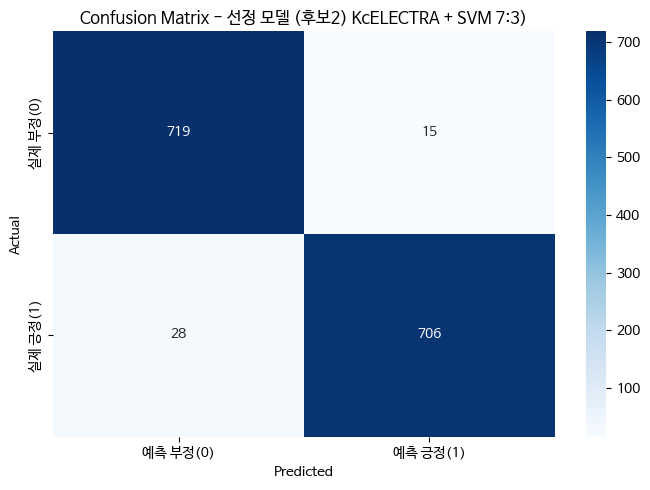


[저장] test_result.txt (비교 실험 요약) 생성 완료!


In [9]:
# ===== 최종 모델 선정 결과 (동일 Test set / 동일 지표) =====
import numpy as np, datetime
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix

cands = [
    ("후보1) KLUE-RoBERTa 단독",       roberta_acc, roberta_f1, roberta_pred),
    ("후보2) KcELECTRA + SVM 7:3",     svm_ens_acc, svm_ens_f1, ens_svm_pred),
    ("후보3) KcELECTRA + Bi-LSTM 7:3", lstm_ens_acc, lstm_ens_f1, ens_lstm_pred),
]

print("=" * 60)
print(" 기능 1 - 최종 모델 선정 결과 (동일 Test set / 동일 지표)")
print("=" * 60)
print(f"{'후보':<30}{'Accuracy':>10}{'Macro-F1':>10}")
print("-" * 60)
for name, acc, f1, _ in cands:
    print(f"{name:<30}{acc:>10.4f}{f1:>10.4f}")
print("-" * 60)

# Macro-F1 을 1차 기준으로 최종 모델 선정
winner = max(cands, key=lambda c: c[2])
w_name, w_acc, w_f1, w_pred = winner
print(f"\n✅ 최종 선정 모델: {w_name}")
print(f"   (Macro-F1 {w_f1:.4f} / Accuracy {w_acc:.4f} 기준)")
print("   * 세 후보 성능이 근소하여, 가장 높은 Macro-F1 모델을 채택했습니다.")
print("   * 정식 학습·평가는 sentiment_analysis.ipynb 에서 진행합니다.")

# 선정 모델 Confusion Matrix
try:
    import matplotlib.font_manager as fm
    for fp in fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum/']):
        fm.fontManager.addfont(fp)
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    pass

cm = confusion_matrix(y_test, w_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['예측 부정(0)', '예측 긍정(1)'],
            yticklabels=['실제 부정(0)', '실제 긍정(1)'])
plt.title(f'Confusion Matrix - 선정 모델 ({w_name})')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('model_selection_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

# 요약 결과 파일 저장 (test_result.txt)
lines = [
    "=" * 60,
    "[기능 1 - 최종 모델 선정용 비교 실험] 요약 결과",
    "=" * 60,
    "",
    "- 데이터: AIHub 감성대화 말뭉치 / 이진 분류(기쁨=긍정, 그 외=부정)",
    f"- 분할  : Stratified 8:1:1 (seed=42)  Train {len(train_df)} / Val {len(val_df)} / Test {len(test_df)}",
    f"- 지표  : Accuracy, Macro-F1  (동일 Test {len(y_test)}개로 1회 측정)",
    "",
    "[후보별 성능]",
]
for name, acc, f1, _ in cands:
    lines.append(f"- {name:<28} Accuracy {acc:.4f} / Macro-F1 {f1:.4f}")
lines += [
    "",
    f"[최종 선정] {w_name}  (Macro-F1 {w_f1:.4f} / Accuracy {w_acc:.4f})",
    "- 선정 기준: 세 후보가 근소하여 가장 높은 Macro-F1 채택",
    "- 정식 학습·평가: sentiment_analysis.ipynb (result.txt)",
    "",
    "[적법성] 학습=Train만 / 모델선택=Validation / 측정=Test 1회 (테스트셋 누출 없음)",
    f"[기록 시각] {datetime.datetime.now():%Y-%m-%d %H:%M:%S}",
    "",
]
with open("test_result.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(lines))
print("\n[저장] test_result.txt (비교 실험 요약) 생성 완료!")